# Семинар. Регуляризация на реальных данных

В этом ноутбуке мы увидим, как регуляризация помогает бороться с мультиколлинеарностью на примере реальных данных [Всемирного Банка](https://data.worldbank.org/).

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme("notebook", font_scale=1.3, palette="Set2")

import warnings

warnings.simplefilter(action="ignore")

RANDOM_STATE = 42



---



## Введение

[Данные Всемирного Банка](https://data.worldbank.org/) &mdash; это обширная библиотека, в которой собирается многолетняя статистика различных данных со всего мира.

А именно, нас интересует датасет [World Development Indicators](https://datacatalog.worldbank.org/search/dataset/0037712). Это &mdash; многомерная таблица, которая включает в себя разнообразные показатели (индикаторы), собранные по различным странам за определенные года. Они охватывают широкий спектр областей, включая экономики стран, демографию, социальное развитие, образование, экологию и многое другое. Вот список лишь некоторых из них:

*   **Охват начальным образованием** (`Adjusted net enrollment rate, primary (% of primary school age children)`)
 &mdash; процент детей школьного возраста, посещающих начальную или среднюю школу.
*   **Индекс качества кредитной осведомлённости**`(Depth of credit information index (0=low to 8=high))`– показывает уровень доступности информации о кредитах для населения. Высокий индекс означает, что граждане имеют больше информации для принятия решений о кредитовании.
*   **Экспорт или импорт товаров и услуг** – множество показателей, отражающих торговые потоки между странами в различных единицах измерения.
*   **Валовой внутренний/национальный продукт** ([`GDP`](https://en.wikipedia.org/wiki/Gross_domestic_product), [`GNI`](https://en.wikipedia.org/wiki/Gross_national_income#Gross_national_product)) – широкий спектр индикаторов, оценивающих экономическую активность стран в различных нормировках и метриках (например, ВВП [на душу населения](https://en.wikipedia.org/wiki/Gross_domestic_product#GDP_per_capita) и [по паритету покупательской способности](https://en.wikipedia.org/wiki/Purchasing_power_parity)).
*   **Площадь лесов**   (`forest area`) – площадь земли, покрытая деревьями (исключая сельскохозяйственные насаждения и городские парки).
*   **Индекс человеческого капитала** ([`Human capital index (HCI) (scale 0-1)`](https://datacatalog.worldbank.org/indicator/b23f8196-bece-eb11-bacc-000d3a3b9510/Human-capital-index--HCI---scale-0-1-)) – показывает вклад здоровья и образования в производительность труда. Он учитывает долю новорожденных, которые к моменту выхода на рынок труда будут здоровы и образованны. Значения индекса находятся в диапазоне от 0 до 1.
*   **Уровень грамотности** (`Literacy rate`) – показатели грамотности среди взрослых и детей, с разделением по полу.
*   **Процент доучившихся до выпускного класса начальной школы** (`Persistence to last grade of primary, total (% of cohort)`) – доля детей, окончивших начальную школу, от общего числа поступивших в первый класс.
*   **Показатели, связанные с уровнем безработицы** (`Unemployment...`) – различные индикаторы безработицы с разделением по полу и уровню образования.


Каждая строка в этой таблице представляет собой набор данных для определенной страны (или региона) и конкретного показателя за разные годы.

## Смотрим на данные
Скачаем архив `CSV` и посмотрим на основной файл с данными:

In [6]:
df = pd.read_csv("WDICSV.csv")
print(f"Размер таблицы: {df.shape}")
df.head(3)

Размер таблицы: (397936, 68)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.401410,17.911234,18.463874,18.924037,19.437054,20.026254,20.647969,21.165877,21.863139,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.728819,7.005877,7.308571,7.547226,7.875917,8.243018,8.545483,8.906711,9.261320,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.080931,38.422282,38.722108,38.993157,39.337872,39.695279,40.137847,40.522209,41.011132,NaN


Для каждой страны представлено около $1500$ индикаторов. Всего в таблице более $250$ стран.

Итого: $1500 \cdot 250 \sim $ немногим меньше $400$ $000$ строк.

Кодовые имена для стран и индикаторов представлены для краткости записи. Будем пользоваться ими, а чтобы быстро сопоставлять им полные названия, сохраним эти взаимные соответствия в отдельные переменные.

In [7]:
countries = pd.Series(df["Country Name"].values, index=df["Country Code"], name="Country Name")
countries = countries[~countries.index.duplicated(keep="first")]
countries.head(3)

,Country Name
Country Code,
AFE,Africa Eastern and Southern
AFW,Africa Western and Central
ARB,Arab World


In [8]:
indicators = pd.Series(
    df["Indicator Name"].values, index=df["Indicator Code"], name="Indicator Name"
)
indicators = indicators[~indicators.index.duplicated(keep="first")]
indicators.sample(3, random_state=RANDOM_STATE)

,Indicator Name
Indicator Code,
DT.NFL.UNTA.CD,"Net official flows from UN agencies, UNTA (cur..."
GC.TAX.TOTL.GD.ZS,Tax revenue (% of GDP)
SP.POP.65UP.TO.ZS,Population ages 65 and above (% of total popul...


Убедимся в том, что данные соответствуют приведённому описанию. Для этого сгруппируем их по странам и посчитаем количество записей по столбцам:

In [9]:
df_groupped = df.groupby("Country Name").count()
df_groupped.sample(7, random_state=RANDOM_STATE)

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Country Name,,,,,,,,,,,,,,,,,,,,,
Northern Mariana Islands,1496,1496,1496,83,86,86,86,86,89,86,...,191,201,189,189,190,190,180,130,104,75
Jamaica,1496,1496,1496,181,203,217,221,212,220,232,...,1052,1030,1076,1057,1076,991,863,806,680,355
Liberia,1496,1496,1496,125,151,156,160,155,161,161,...,923,780,903,886,753,749,763,673,573,197
Small states,1496,1496,1496,117,127,129,128,129,133,130,...,766,771,753,746,756,725,654,605,524,303
Chile,1496,1496,1496,261,285,307,314,309,318,317,...,1072,1150,1074,1133,996,987,970,862,766,423
Uzbekistan,1496,1496,1496,86,89,89,89,89,91,89,...,1027,1030,1008,1024,1034,1028,986,930,759,416
Luxembourg,1496,1496,1496,135,133,136,135,135,139,144,...,1034,1034,1009,1004,971,975,954,857,721,369


Действительно, каждая страна формально представлена 1496 строками в таблице. Составители организовали датасет так, чтобы набор индикаторов был одинаков для всех. Однако, судя по конкретным годовым статистикам, по многим показателям есть пропущенные значения, и мало где число записей достигает хотя бы 1000.

Поскольку человеческому глазу приятнее видеть цветовую палитру, нежели голые числа, преобразуем полученную таблицу в картинку и взглянем на неё целиком. Для этого можно воспользоваться функцией [`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) библиотеки *seaborn*.

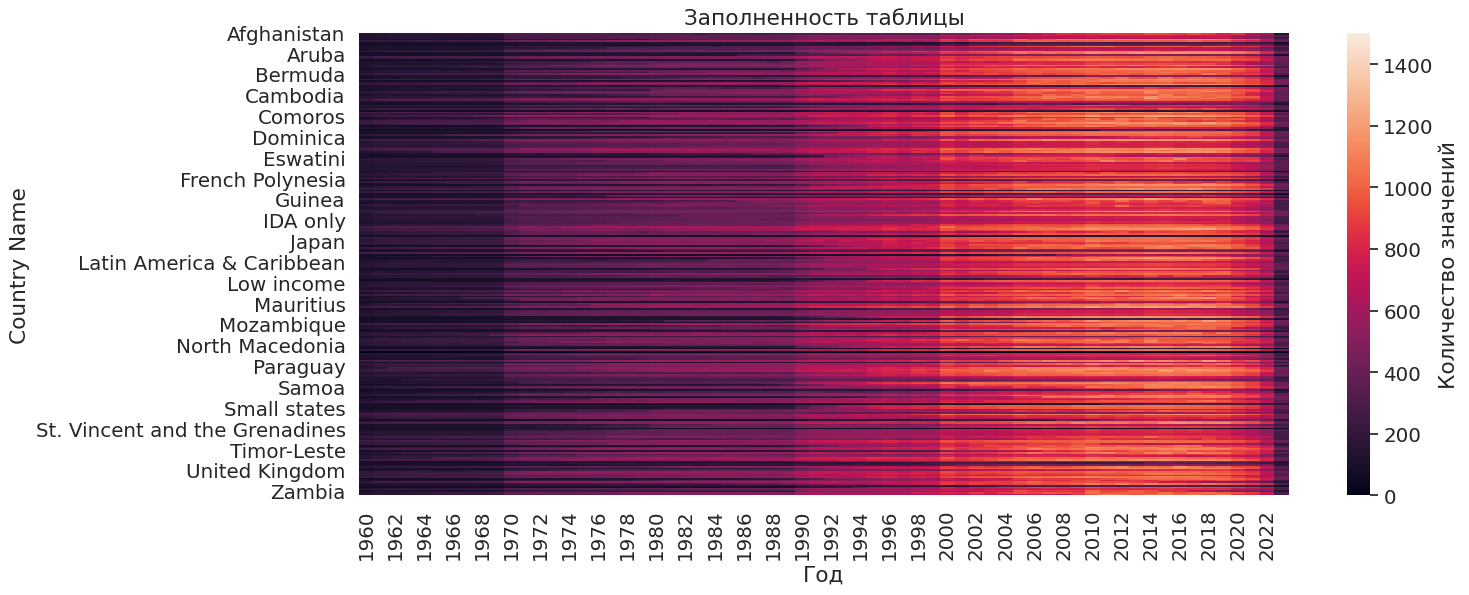

In [10]:
plt.figure(figsize=(15, 6))

sns.heatmap(df_groupped.iloc[:, 3:], cbar_kws={"label": "Количество значений"}, vmax=1500)
plt.title("Заполненность таблицы")
plt.xlabel("Год");

🎲 **НЕБОЛЬШОЙ ИНТЕРАКТИВ** 🎲

> Полученный график намного интереснее, чем может показаться на первый взгляд. Какие закономерности видны на графике? С какими важными событиями мировой истории их можно связать?  
>  
> 🔍 Подумайте сами, обсудите с соседом 😉  

<details>
  <summary>💡 Спойлер (нажмите, чтобы раскрыть)</summary>

Рисунок наглядно иллюстрирует эволюцию датасета. Ниже приводим ряд событий, наиболее вероятно повлиявших в своё время на нынешний облик базы данных WDI.

  1. 🌍 **Расширение роли глобальных институтов (с 1970-х)**  
     Самый первый скачок в 1970-м, по-видимому, обусловлен усилением поддержки развивающихся стран со стороны Всемирного Банка и других международных организаций.
     Это могло вызвать резкий рост объёма доступных данных начиная с 1970-х годов.

  2. 🧱 **Распад СССР (1990–1991)**  
     Возникновение новых независимых государств расширило базу данных, скачком увеличив число записей в таблице

  3. 🌐 **Цифровизация и интернет (с 2000-х)**  
     Электронная отчётность, унификация форматов и рост прозрачности сильно облегчили и ускорили сбор данных. Появлялись новые индикаторы, по которым ранее статистика не велась.

  4. 🦠 **Пандемия COVID-19 (2020–2023)**  
     В разгар пандемии внимание было сосредоточено на сборе экстренной медицинской статистики.  
     Остальные направления могли временно "просесть" — отсюда рост числа пропусков.

</details>


Для упрощения дальнейшей работы оставим только 2022 год: выделим индикаторы в столбцы, а страны расположим в построчно:

In [11]:
df22 = df.pivot_table(
    index="Country Code", columns="Indicator Code", values="2022", aggfunc="first"
)
df22.sample(5, random_state=RANDOM_STATE)

Indicator Code,AG.LND.CREL.HA,AG.PRD.CREL.MT,AG.PRD.CROP.XD,AG.PRD.FOOD.XD,AG.PRD.LVSK.XD,AG.YLD.CREL.KG,BG.GSR.NFSV.GD.ZS,BM.GSR.CMCP.ZS,BM.GSR.FCTY.CD,BM.GSR.GNFS.CD,...,VA.EST,VA.NO.SRC,VA.PER.RNK,VA.PER.RNK.LOWER,VA.PER.RNK.UPPER,VA.STD.ERR,VC.BTL.DETH,VC.IDP.NWCV,VC.IDP.NWDS,VC.IDP.TOCV
Country Code,,,,,,,,,,,,,,,,,,,,,
NZL,113518.0,967398.93,108.20,100.57,99.00,8522.0,11.645655,45.100731,1.409778e+10,7.134960e+10,...,1.639671,10.0,99.516907,94.685989,100.000000,0.137781,NaN,NaN,2800.0,NaN
ITA,3010620.0,14300570.00,93.95,96.97,102.34,4750.0,12.904907,44.904146,8.588524e+10,7.855490e+11,...,1.070306,10.0,82.608696,75.362320,89.371979,0.108861,NaN,NaN,4100.0,NaN
HKG,0.0,0.06,101.49,141.66,149.97,2079.6,40.787834,45.344914,2.071293e+11,6.828809e+11,...,-0.406678,9.0,35.265701,29.951691,40.579712,0.138847,NaN,NaN,330.0,NaN
BIH,207036.0,1431169.00,128.06,113.39,83.81,6912.7,15.812834,19.064109,1.058158e+09,1.516245e+10,...,-0.325713,9.0,37.681160,32.850243,42.028984,0.127861,NaN,NaN,78.0,91000.0
ARG,18063791.0,91584182.57,107.33,109.39,113.91,5070.0,5.648610,39.767467,1.540821e+10,9.739913e+10,...,0.543527,12.0,62.801933,58.454105,70.531403,0.127701,NaN,NaN,730.0,NaN


Можно видеть, что за этот год суммарно по всему миру было собрано 1063 показателя из имеющихся 1496.

## Постановка задачи
Пожалуй, самое сложное при работе с базой данных [WDI](https://datacatalog.worldbank.org/search/dataset/0037712) &mdash; это понять, какие индикаторы необходимо извлечь исследователю для конкретной задачи.

Представим, что к нам обратились экологи, исследующие различные подходы по снижению углеродного следа человечества. Им известно, что в датасете [WDI](https://datacatalog.worldbank.org/search/dataset/0037712) точно есть данные, отражающие объёмы выбросов CO$_2$ в атмосферу каждой отдельно взятой страной. Разумно также полагать, что среди 1496 индикаторов может оказаться много тех, которые прямо или косвенно на эти выбросы влияют. Например,
1.   ВВП на душу населения
2.   Общий объём промышленности
3.   Доля городского населения
4.   Потребление электроэнергии из возобновляемых источников

Но могут быть и менее очевидные. Нам необходимо сократить количество индикаторов до разумных пределов и оценить вклад каждого из них.

### Проблемы

Если полистать файл с данными (есть "эксель"), то легко убедиться, что ручной отбор &mdash; занятие неблагодарное:
*   Во-первых, каждый признак (индикатор) варьируется год от года. Да и самих признаков &mdash; полторы тысячи!
*   Во-вторых, многие индикаторы представлены во множестве форм: разные размерности и нормировки, где-то есть разделение по полу, возрасту или иным параметрам. Да что уж говорить, даже интересующие нас выбросы CO$_2$ представлены в нескольких вариациях:

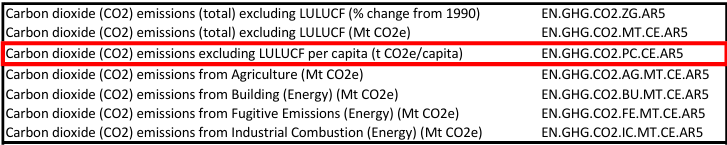

*   В-третьих, как мы убедились выше, в данных много пропусков, причём их распределение по датасету может сильно меняться во времени.

### Как быть?

Одним из возможных путей решения является отбор при помощи **линейной регрессии**. При этом нет нужды гнаться за высокой точностью предсказания: понятно, что в истинную зависимость входят и факторы, не отражённые в датасете.
Если нам удастся построить хоть сколь-нибудь рабочую модель, то её коэффициенты позволят отранжировать признаки по "степени важности", а также могут дать информацию о величине и знаке эффекта ($\widehat{θ}_i > 0$ будет означать влияние в сторону увеличения выбросов, $\widehat{θ}_i < 0$ &mdash; в сторону снижения).

## 1. Подготовка данных

### 1.1 Выделение таргета и признаков

Рассмотрим в качестве таргета индикатор `"Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"` &mdash;   **общий объём выбросов углекислого газа на душу населения за год.** Остальные "синонимы" подлежат удалению:

In [12]:
y = df22["EN.GHG.CO2.PC.CE.AR5"]

target_like_features = df22.filter(like="CO2").columns.to_list() + [
    "EN.GHG.TOT.ZG.AR5",
    "EN.GHG.ALL.MT.CE.AR5",
    "EN.GHG.ALL.PC.CE.AR5",
    "EN.GHG.ALL.LU.MT.CE.AR5",
]
print(f"Удалено {len(target_like_features)} элементов")
# Удалим лишние "таргеты"
X = df22.drop(columns=target_like_features, errors="ignore")

Удалено 17 элементов


Помимо отдельных стран, в данных встречаются и более общие понятия, например, *“Мир”, “Европейский союз”, “Страны с высоким уровнем задолженности” и т.д.:*

In [13]:
not_countries = [
    "AFE", "ARB", "CEB", "EAP", "EAR", "EAS", "ECA", "ECS", "EMU", "EUU",
    "FCS", "HIC", "HPC", "IBD", "IBT", "IDA", "IDB", "IDX", "LAC", "LCN",
    "LDC", "LIC", "LMC", "LMY", "LTE", "MEA", "MNA", "NAC", "OED", "OSS",
    "PRE", "PST", "SSA", "SSF", "SST", "TEA", "TEC", "TLA", "TMN", "TSA",
    "TSS", "UMC", "WLD"
]
print("Всего аггрегированных регионов:", len(not_countries))
countries[not_countries].sample(3, random_state=RANDOM_STATE)

Всего аггрегированных регионов: 43


,Country Name
Country Code,
TLA,Latin America & the Caribbean (IDA & IBRD coun...
LTE,Late-demographic dividend
MEA,Middle East & North Africa


&#x2753; **Вопрос** &#x2753;

> Правильно ли будет убрать их? Почему?

<details>
  <summary> Кликни для показа ответа </summary>
  
> При желании можно оставить, но тогда придётся следить за тем, чтобы группа и образующие её государства всегда находились в одной подвыборке. Иначе в тестовую выборку попадёт информация об обучающей, и получим переобучение. Проще будет избавиться от них.

</details><br/>

### 1.2 Естественный отбор признаков

>🚀 *При первом чтении здесь можно сразу перейти к разделу 2.*

Итак, мы имеем около **1000 признаков** для более чем **200 объектов**:

In [14]:
# Удаляем сгруппированные регионы
X.drop(index=not_countries, inplace=True)
y.drop(index=not_countries, inplace=True)
X.shape, y.shape

((222, 1047), (222,))

Если в таргете есть пропуски, то соответствующие объекты придётся удалить:

In [15]:
y.dropna(inplace=True)
X = X.loc[y.index]
X.shape, y.shape

((208, 1047), (208,))

Теперь посчитаем пропуски в матрице $X$ и нарисуем гистограмму:

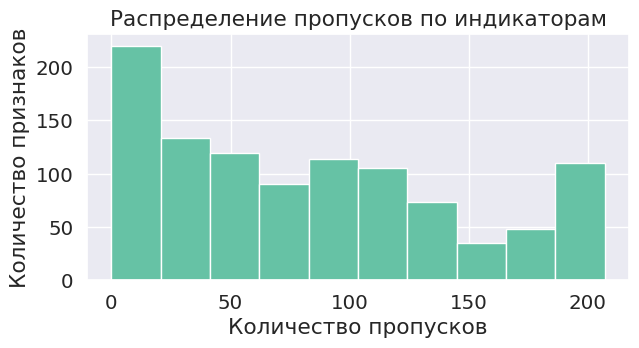

In [16]:
nans = X.isna().sum()

plt.figure(figsize=(7, 3.2))
nans.hist()
plt.xlabel("Количество пропусков")
plt.ylabel("Количество признаков")
plt.title("Распределение пропусков по индикаторам");

Понятно, что 100-200 пропущенных значений на 220 объектов никуда не годится &mdash; их придётся удалить. Зададим некоторый порог на допустимое число пропусков:

In [17]:
# Задаём порог
threshold = 50

# Удаляем
X.drop(columns=X.columns[nans > threshold], inplace=True)
print(f"Осталось {len(X.columns)} признаков с менее чем {threshold} пропущенными значениями")

Осталось 415 признаков с менее чем 50 пропущенными значениями


Разделим выборку на обучающую и тестовую части:

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((124, 415), (84, 415), (124,), (84,))

Здесь мы отвели на тест внушительную долю, т.к. в выборка небольшая.

### 1.3 Стандартизация

Напомним, что мы собираемся сортировать индикаторы исходя из соответствующих коэффициентов линейной регрессии, поэтому важно всё обезразмерить. Стандартизируем наши фичи:

In [19]:
# Инициализируем класс
scaler = StandardScaler().set_output(transform="pandas")

# Преобразуем обучающую и валидационную выборки
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 1.4 Заполняем пропуски

Оставшиеся пропуски заполним медианами: вместо каждого NaN поставим медианное значение признака, посчитанное без учёта этих самых NaN.

**❗Важно: и в обучающей, и в тестовой выборке пропуски заполняются медианами, посчитанными ТОЛЬКО на обучающей выборке.**

Для подобных преобразований удобно воспользоваться трансформером [`sklearn.SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html):

In [20]:
imputer = SimpleImputer(strategy="median").set_output(transform="pandas")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

Проверим, что всё преобразовалось корректно, и пропусков в данных нет:

In [21]:
np.any(X_train.isna()), np.any(X_test.isna())

(np.False_, np.False_)

### 1.5 Отбор признаков линейной регрессией по одному параметру

Из оставшихся признаков имеет смысл отобрать те, по которым таргет можно считать более или менее линейным. Для этого построим линейную регрессию отдельно для каждой фичи и вычислим коэффициент детерминации $R^2$:

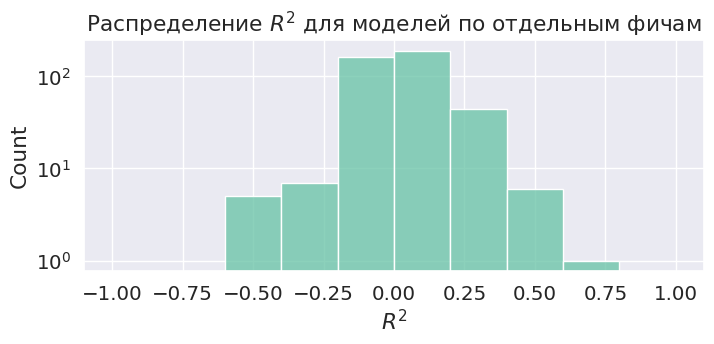

In [22]:
# Сюда будем записывать R2
r2 = pd.Series(index=X_train.columns, dtype=float)

for feature in X_train.columns:

    model_1d = LinearRegression()
    model_1d.fit(X_train[feature].values.reshape(-1, 1), y_train)
    r2[feature] = r2_score(y_test, model_1d.predict(X_test[feature].values.reshape(-1, 1)))

plt.figure(figsize=(8, 3))
sns.histplot(r2, bins=10, binrange=(-1, 1))
plt.title("Распределение $R^2$ для моделей по отдельным фичам")
plt.xlabel("$R^2$")
plt.yscale("log");

**Вывод:** есть признаки c $R^2 < 0$.

Попробуем оставить только те, для которых линейная регрессия даёт $ R^2 $ выше некоторого порога:

In [23]:
# Порог установим с небольшим запасом
threshold = 0.1
features_to_exclude = X.columns[r2 < threshold]

X_train.drop(columns=features_to_exclude, inplace=True, errors="ignore")
X_test.drop(columns=features_to_exclude, inplace=True, errors="ignore")
X_train.shape, X_test.shape

((124, 119), (84, 119))

Мы сократили число признаков примерно в 10 раз, даже не глядя на их названия!

Теперь можно пробовать подобрать подходящуюю линейную модель для оценки их относительного вклада в общий котёл.

## 2. Что не так с методом наименьших квадратов?

Попробуем аппроксимировать данные простой **линейной регрессией**. Обучим модель, посчитаем коэффициент детерминации [$R^2$](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html) и [RMSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html) на тесте:

In [24]:
# Инициализация модели и обучение
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = linear_model.predict(X_test)

print(f"R2: {r2_score(y_test, y_pred):.2f} \nRMSE: {root_mean_squared_error(y_test, y_pred):.2f}")

R2: -46.54 
RMSE: 47.34


**Вывод**: полученный $R^2$ говорит о том, что такая аппроксимация работает хуже, чем простое предсказание средним `y_pred = y_train.mean()`.

Действительно:

In [25]:
# Предсказание средним значением таргета на обучающей выборке
y_pred_mean = y_train.mean() * np.ones_like(y_test)

print(
    f"R2: {r2_score(y_test, y_pred_mean):.2f} \nRMSE: {root_mean_squared_error(y_test, y_pred_mean):.2f}"
)

R2: -0.00 
RMSE: 6.87


Изобразим на одном графике распределение ошибок на тесте, а также отклонение тестовых объектов от `y_train_mean`.

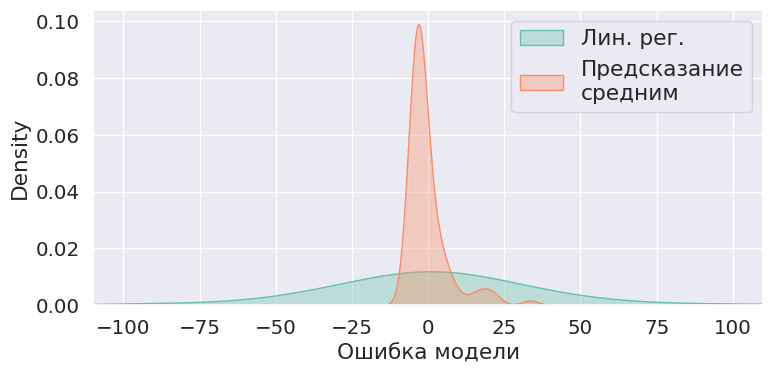

In [26]:
plt.figure(figsize=(8, 4), tight_layout=True)

sns.kdeplot(y_test.values - y_pred, fill=True, alpha=0.35, label="Лин. рег.")
sns.kdeplot(y_test.values - y_pred_mean, fill=True, alpha=0.35, label="Предсказание\nсредним")
plt.legend(fontsize="medium")
plt.xlim((-110, 110))
plt.xlabel("Ошибка модели");

**Вывод:** действительно, такая модель менее информативна, чем простое усреднение.

Итак, наше желание обойтись малой кровью упирается в низкий коэффициент детерминации. Перечислим факторы, которые могли на это повлиять:

1.   Функциональная зависимость между фичами и таргетом могла оказаться нелинейной. Это &mdash; наиболее очевидное предположение, однако, даже в таком случае вполне естественно желать выявить линейную взаимосвязь таргета и определённых факторов.
2.   Зависимость всё же близка к линейной, но признаки оказались "псевдо-зависимы", или **мультиколлинеарны**.
3. Зависимость нелинейна, а признаки мультиколлинеарны.

Будем надеяться на пункт 2 и исследуем, есть ли зависимости между отдельными признаками.

## 3. Как распознать мультиколлинеарность?

Быстрый ответ такой: если признаков **очень много**, скорее всего, они **мультиколлинеарны**. Но давайте копнём поглубже.

### 3.1 Число обусловленности

Число обусловленности (condition index) матрицы — это мера того, насколько чувствительно решение системы линейных уравнений $X\theta = y$ к изменениям в $y$ или в самой матрице $X$. Чем выше число обусловленности, тем больше может увеличиваться ошибка в решении при небольших изменениях в признаках и таргете.

> *Для прямоугольной матрицы $X$ оно равно корню из отношения наибольшего и наименьшего собственных числел матрицы $X^TX$:*
$$
    \text{CI}(X) = \sqrt{\frac{\lambda_1}{\lambda_n}}
$$


Найдём число обусловленности нашей тренировочной матрицы:

In [27]:
np.linalg.cond(X_train)

np.float64(1.0149325156862309e+17)

**Вывод:**
число обусловленности огромно, простая линейная модель будет крайне чувствительна к шуму в данных.

### 3.1 Матрица корреляций

Построение матрицы корреляций позволяет количественно оценить вклад парных зависимостей между признаками.

> Коэффициент корреляции &mdash; мера того, насколько хорошо точки ложатся на прямую:
>
> $$
> r(X, Y) = \frac{\sum\limits_{i=1}^n\left(X_i - \overline{X}\right)\left(Y_i - \overline{Y}\right)}{\sqrt{\sum\limits_{i=1}^n\left(X_i - \overline{X}\right)^2}\sqrt{\sum\limits_{i=1}^n\left(Y_i - \overline{Y}\right)^2}} = \frac{cov\left(X, Y\right)}{S_X \cdot S_Y}
> $$
> *   $X$ и $Y$ &mdash; векторы признаков длины $n$,
> *   $S$ &mdash; выборочные среднеквадратичные отклонения,
> *   $cov$ &mdash; выборочная ковариация,
> *   $\overline{X}$ и $\overline{Y}$ &mdash; выборочные средние $X$ и $Y$.

Чем ближе $r$ к $\pm1$, тем выше степень линейной зависимости между признаками.
На графике это выглядит так:

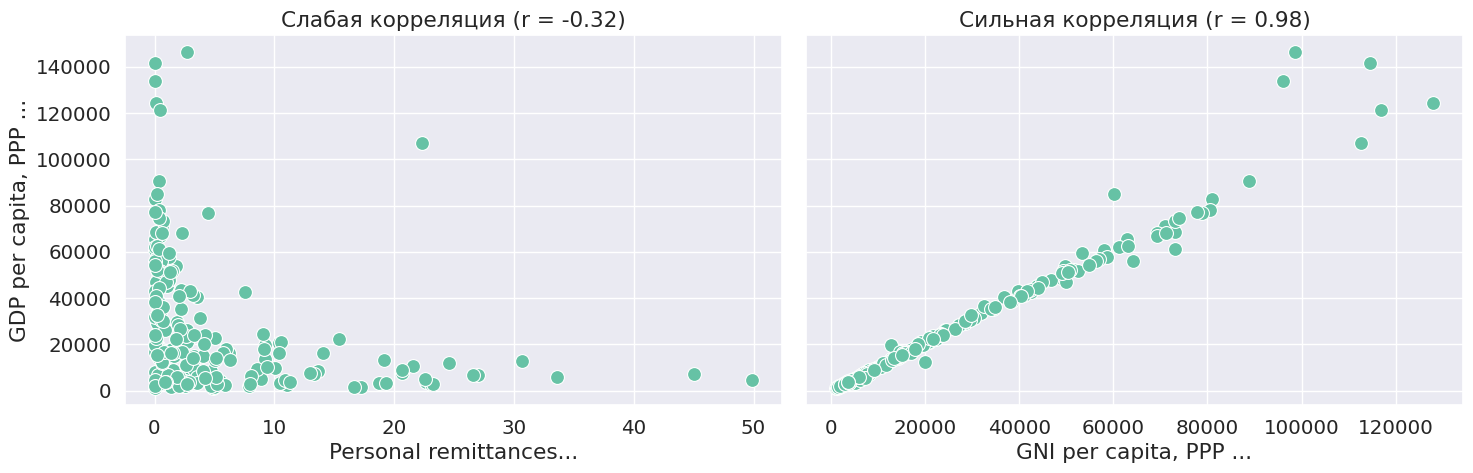

In [28]:
def cut_str(s: str, max_length: int = 30):
    """Обрезает строку `s`, если число символов в ней превосходит `max_length`"""
    return s[:max_length] + "..." if len(s) > max_length else s


fig, (ax_low_corr, ax_high_corr) = plt.subplots(
    1, 2, figsize=(15, 5), sharey=True, tight_layout=True
)

# Выберем индикаторы для сравнения
compared = "NY.GDP.PCAP.PP.CD"
indicators_to_compare = [
    ("NY.GNP.PCAP.PP.CD", "Сильная корреляция", ax_high_corr),
    ("BX.TRF.PWKR.DT.GD.ZS", "Слабая корреляция", ax_low_corr),
]
# Объединим их в один массив и удалим выбросы
sub_X = X[[compared] + [i[0] for i in indicators_to_compare]].dropna()

for ind, title, ax in indicators_to_compare:
    # Отображаем зависимость между значениями индикаторов
    sns.scatterplot(x=sub_X[ind], y=sub_X[compared], ax=ax, s=100)
    # Настраиваем подписи
    ax.set_xlabel(cut_str(indicators[ind], 20))
    # Вычисляем коэффициент корреляции
    corr = np.corrcoef(sub_X[ind], sub_X[compared])[0, 1]
    ax.set_title(f"{title} (r = {corr:.2f})")

ax_low_corr.set_ylabel(cut_str(indicators[compared], 20));

Удобнее всего отобразить коэффициенты корреляции в виде матрицы:

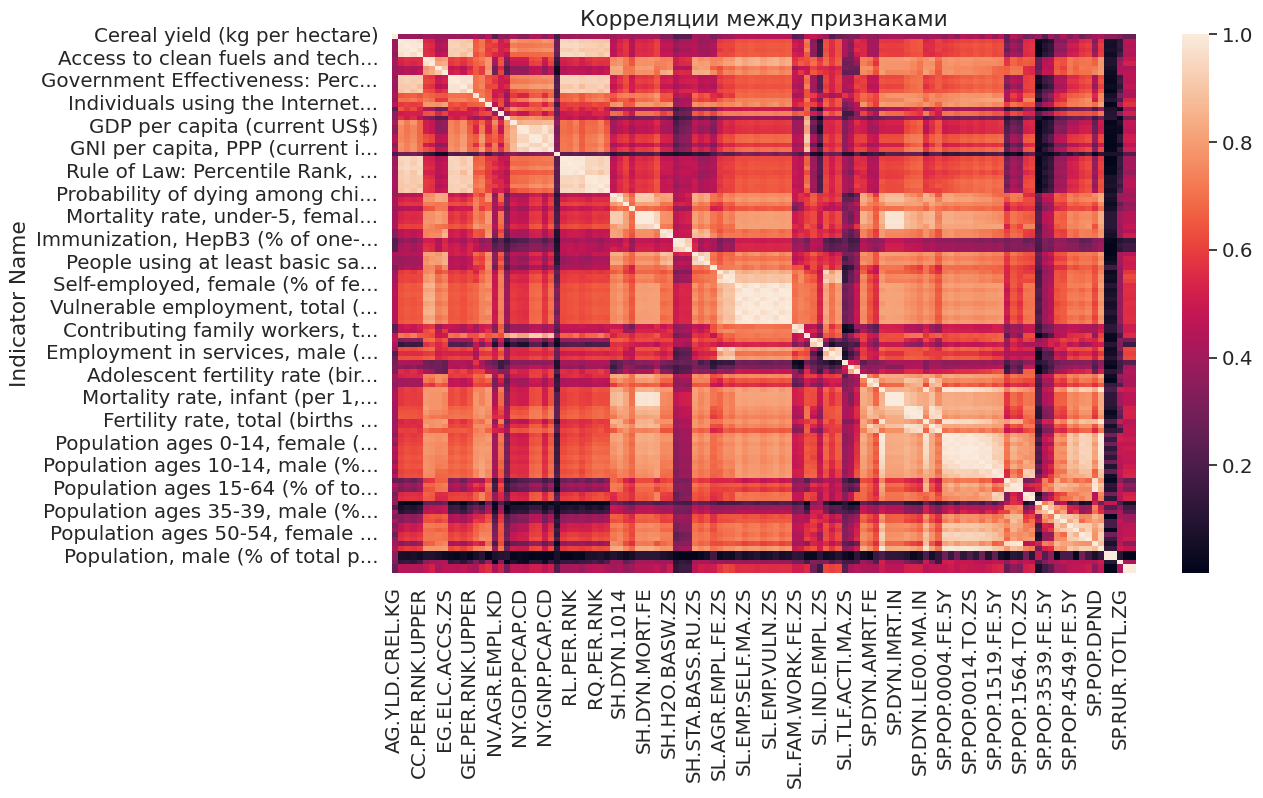

In [29]:
# Считаем модуль корреляции между индикаторами и визуализируем что получилось
corr_matrix = X_train.corr().abs()

# Переименуем индексы массива в полные названия
corr_matrix.index = indicators[corr_matrix.index].apply(cut_str)

# Визуализация
plt.figure(figsize=(12, 7))
sns.heatmap(corr_matrix).set(title="Корреляции между признаками");

**Вывод:** наблюдаем много светлых пикселей &mdash; высоких коэффициентов корреляции (не считая главную диагональ). Это неудивительно, поскольку многие индикаторы отражают близкие по своей сути вещи, но выражаются в разных метриках или, например, собраны по разным группам населения.

  ### 3.3 Коэффициент вздутия дисперсии ([Variance Inflation Factor](https://en.wikipedia.org/wiki/Variance_inflation_factor#cite_note-1) &mdash; VIF)

Другим способом продемонстрировать мультиколлинеарность является коэффициент VIF. Будем строить линейную модель, используя в качестве целевой переменной один из признаков, а остальные &mdash; как независимые переменные. Таким образом, мы проверяем, существует ли между признаками линейная зависимость. Метрика определяется следующим образом:

$$
    VIF_i = \frac{1}{1 - R_i^2},
$$
где $R_i^2$ &mdash; это значение $R^2$ для линейной регрессии $i$-го признака по остальным.

Считается, что
*  $VIF = 1$ &mdash; переменные не коррелируют;
*  $1 < VIF < 10$ &mdash; переменные коррелируют частично
*  $VIF > 10$ &mdash; переменные коррелируют очень сильно.

&#x2753; **Вопрос** &#x2753;

> Чему равны соответствующие $R^2$ ?

<details>
  <summary> Кликни для показа ответа </summary>
  
>&#x1F4A1;
>1. $R^2 = 0$
>2. $0 < R^2 < 0.9$;
>3. $R^2 > 0.9$

</details><br/>

Реализуем функцию подсчёта VIF для одного признака в выборке:

In [30]:
def calculate_single_vif(X_train: pd.DataFrame, feature: str):
    """Вычисляет коэффициент инфляции дисперсии (VIF) для отдельного признака

    Args:
        X_train (pd.DataFrame): обучающая выборка
        feature (str): название признака

    Returns:
        float: значение VIF для указанного объекта.
    """
    # Один из признаков перемещаем в отдельную переменную
    X_VIF, y_VIF = X_train.drop(columns=feature), X_train[feature]

    # Делим выборки на трейн и тест
    X_train_VIF, X_test_VIF, y_train_VIF, y_test_VIF = train_test_split(
        X_VIF, y_VIF, test_size=0.5, random_state=RANDOM_STATE
    )

    # Создание модели, обучение и подсчёт метрики
    model_VIF = LinearRegression()
    model_VIF.fit(X_train_VIF, y_train_VIF)
    r2 = r2_score(y_test_VIF, model_VIF.predict(X_test_VIF))

    return np.inf if r2 == 1 else 1 / (1 - r2)

Посчитаем VIF для всех имеющихся индикаторов и отобразим результаты на гистограмме:

In [31]:
VIFs = []

for feature in X_train.columns:
    VIFs.append(calculate_single_vif(X_train, feature))

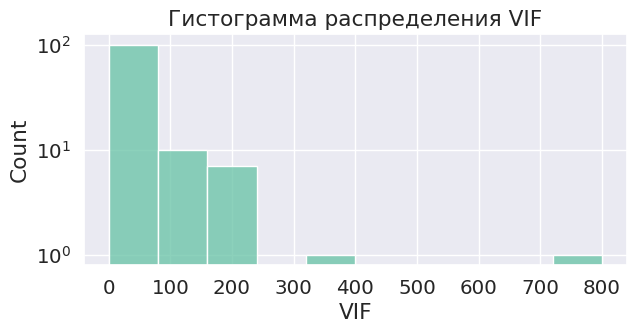

In [32]:
plt.figure(figsize=(7, 3))

sns.histplot(VIFs, bins=10, binrange=(0, 800))
plt.yscale("log")
plt.xlabel("VIF")
plt.title("Гистограмма распределения VIF");

**Вывод:** присутствуют очень большие VIF, что вновь указывает на наличие мультиколлинеарности.

&#x2753; **Вопрос** &#x2753;

> В чём преимущество такой проверки перед подсчётом матрицы корреляций?

<details>
  <summary> Кликни для показа ответа </summary>
  
> VIF учитывает не только парные зависимости, но и комбинации из нескольких фичей.

</details><br/>

Итак, основная причина неудачи с методом наименьших квадратов кроется в мультиколлинеарности. Это неудивительно: как мы уже отмечали выше, многие индикаторы образуют группу близких по смыслу вещей. Взять, хотя бы, ВВП:

In [33]:
indicators[X_train.filter(like="GDP").columns]

,Indicator Name
NY.GDP.PCAP.CD,GDP per capita (current US$)
NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$)
NY.GDP.PCAP.PP.CD,"GDP per capita, PPP (current international $)"
NY.GDP.PCAP.PP.KD,"GDP per capita, PPP (constant 2021 internation..."
SL.GDP.PCAP.EM.KD,GDP per person employed (constant 2021 PPP $)


Разумеется, все они не являются независимыми. Но и выбрать случайный нельзя: откуда нам знать, какой вариант лучше подходит для описания таргета?

И всё-таки нам хотелось бы остаться в рамках линейной модели и иметь возможность делать выводы на основании её коэффициентов.

## 4. Как бороться с мультиколлинеарностью?

Чтобы линейная регрессия сама могла решить, каким из зависимых признаков отдать предпочтение, её нужно регуляризовать.

>### 4.1 Регуляризация в линейной регрессии (краткое напоминание)
>Метод подразумевает под собой некую модификацию метода наименьших квадратов, при которой к функционалу ошибки добавляется штраф за слишком большие значения коэффициентов. Это помогает справиться с мультиколлинеарностью, стабилизируя модель и улучшая её обобщающую способность.
>
> &#x2755;*Замечание*&#x2755; Свободный коэффициент не штрафуется.
>
>В задаче линейной регрессии наиболее часто используют модели
 [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) и [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html).
>
> * **Ridge** &mdash; это модель линейной регрессии с $L_2$-регуляризацией, которая минимизирует функционал
>$$\lVert Y - X \theta\rVert^2_2 + \alpha  \lVert\theta\rVert^2_2 → \min_\theta$$
>* **Lasso** &mdash; модель линейной регрессии с $L_1$-регуляризацией. Минимизирует функционал
>$$\lVert Y - X \theta\rVert^2_2 + \alpha  \lVert\theta\rVert_1 → \min_\theta$$
>* **ElasticNet** &mdash; компромисс между двумя предыдущими. Минимизирует функционал
>$$    \lVert Y - X\theta\rVert^2_2 + \alpha_1  \lVert\theta\rVert_1 + \alpha_2  \lVert\theta\rVert^2_2 → \min_\theta$$
>Здесь $Y \in \mathbb{R}^{n}$ &mdash; истинные значения целевой переменной, $X \in \mathbb{R}^{n\times d}$ &mdash; матрица "объект-признак", ${\theta} \in \mathbb{R}^{d}$ &mdash; коэффициенты модели. Параметр регуляризации $\alpha \geq 0$ управляет силой штрафа. Является **гиперпараметром**, т.е. задаётся пользователем.

Проверим, можно ли с помощью этих моделей получить преемлемый $R^2$.

### 4.2 Применяем методы Ridge и Lasso

Применение линейных моделей с регуляризацией ничем не отличается от линейной регрессии, за исключением лишь того, что нужно задать гиперпараметр $\alpha$. Рассмотрим сразу много различных "альф", чтобы понять, при какой величине достигается наилучшее качество.

In [34]:
# Создаём сетку параметров регуляризации.
# Здесь удобнее работать с логарифмической шкалой
alphas = {"lasso": np.logspace(-5, 2, 500), "ridge": np.logspace(-4, 7, 500)}

# Создаём списки, куда будем записывать метрику качества
r2_train = {"lasso": [], "ridge": []}
r2_test = {"lasso": [], "ridge": []}

# Сами модели тоже в словарь
models = {"lasso": Lasso(), "ridge": Ridge()}

for model_name, model in models.items():

    for alpha in alphas[model_name]:

        # Устанавливаем очередное альфа и обучаем
        model.set_params(alpha=alpha)
        model.fit(X_train, y_train)

        # Считаем метрику и добавляем в списки
        r2_test[model_name].append(r2_score(y_test, model.predict(X_test)))
        r2_train[model_name].append(r2_score(y_train, model.predict(X_train)))

Сохраняем наилучшие гиперпараметры:

In [35]:
best_alpha_lasso = alphas["lasso"][np.argmax(r2_test["lasso"])]
best_alpha_ridge = alphas["ridge"][np.argmax(r2_test["ridge"])]
print(
    f'Для Lasso: R2_best = {np.max(r2_test["lasso"]):.2f} (test) '
    f"при alpha = {best_alpha_lasso:.2f}\n"
    f'Для Ridge: R2_best = {np.max(r2_test["ridge"]):.2f} (test) '
    f"при alpha = {best_alpha_ridge:.2f}"
)

Для Lasso: R2_best = 0.69 (test) при alpha = 0.41
Для Ridge: R2_best = 0.65 (test) при alpha = 115.38


Визуализация:

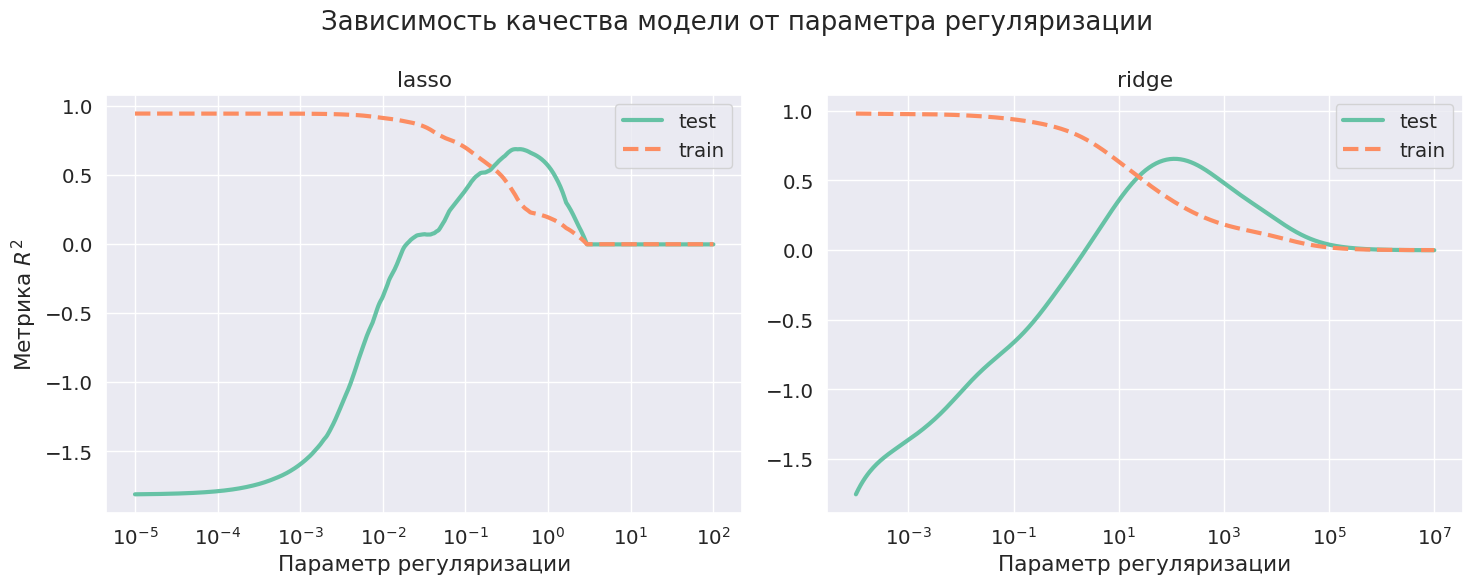

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

for ax, model_name in zip(axes, alphas.keys()):

    ax.plot(alphas[model_name], r2_test[model_name], label="test", lw=3, ls="-")
    ax.plot(alphas[model_name], r2_train[model_name], label="train", lw=3, ls="--")
    ax.set_xscale("log")  # Логарифмический масштаб
    ax.set_xlabel("Параметр регуляризации")
    ax.set_title(model_name)
    ax.legend()

axes[0].set_ylabel("Метрика $R^2$")
fig.suptitle("Зависимость качества модели от параметра регуляризации");

**Выводы**

1.  На графиках наблюдается общая асимптотика при $\alpha → +∞$: штрафы становятся настолько большими, что все коэффициенты становятся равны или стремятся к нулю, и предсказание сводится к среднему таргету на тренировочной выборке (когда $R^2 \approx 0$).

2. При $\alpha → 0$ модели должны стремиться к МНК.

3.  Можно заметить разную "гладкость" функций. Lasso-регрессия резко обнуляет коэффициенты один за другим, что приводит к скачкообразным изменениям метрики. Ridge-регрессия всегда плавно меняет свои коэффициенты.

4. Регуляризация эффективно борется с переобучением: метрика на тестовой выборке улучшается, в то время как на тренировочной — ухудшается.

### 4.3 Применяем ElasticNet

Так как это комбинация двух предыдущих моделей, то и гиперпараметров необходимо задавать два: `alpha`, `l1_ratio`. Связь между ними и $\alpha_1, \alpha_2$, которые мы вводили ранее, выглядит так:

$$
\verb|alpha| = \alpha_1 + 2\alpha_2
\\
\verb|l1_ratio| = \frac{\alpha_1}{\alpha_1 + 2\alpha_2}
\\
\alpha_1 = \verb|alpha| \cdot \verb|l1_ratio|
\\
\alpha_2 = \frac{1}{2} \verb|alpha| \cdot (1 - \verb|l1_ratio|)
$$

Грубо говоря, `alpha` контролирует общую силу штрафа, а `l1_ratio` распределяет влияние между слагаемыми.

Аналогично, будем обучать модели с разными `alpha`, `l1_ratio`, чтобы увидеть наилучшую комбинацию.

In [37]:
# Задаём сетки гиперпараметров
alphas = np.logspace(-2, 2, 50)
l1_ratios = np.linspace(0, 1.0, 50)

# Метрика качества - функция двух переменных alpha и l1_ratio,
# поэтому создаём пустой двумерный массив
r2_elastic = np.empty((len(l1_ratios), len(alphas)))

# Итерируемся по всем комбинациям alpha и l1_ratio
for alpha_idx, alpha in enumerate(alphas):
    for l1r_idx, l1_ratio in enumerate(l1_ratios):

        # Создаём модель ElasticNet
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=RANDOM_STATE)

        # Обучаем
        model.fit(X_train, y_train)

        # Делаем предсказание
        y_pred = model.predict(X_test)

        # Считаем метрику и сохраненяем в массив
        r2_elastic[l1r_idx, alpha_idx] = r2_score(y_test, y_pred)

Сохраняем наилучшие гиперпараметры:

In [38]:
arg = np.argmax(r2_elastic)

best_elastic = {
    "alpha": float(round(alphas[arg % alphas.size], 2)),
    "l1_ratio": float(round(l1_ratios[arg // l1_ratios.size], 2)),
}

print(f"R2_best = {np.max(r2_elastic):.2f} при {best_elastic}")

R2_best = 0.69 при {'alpha': 0.43, 'l1_ratio': 0.94}


**Вывод:** в нашем случае комбинация из двух видов регуляризации не даёт преимущества по метрике $R^2$.

### 4.4 Визуализируем коэффициенты

Фиксируем оптимальные параметры, которые мы нашли и заново обучим МНК, Ridge и Lasso:

In [39]:
models = {
    "Linear": LinearRegression().fit(X_train, y_train),
    "Ridge": Ridge(alpha=best_alpha_ridge).fit(X_train, y_train),
    "Lasso": Lasso(alpha=best_alpha_lasso).fit(X_train, y_train),
}
# Коэффициенты моделей сохраним в виде DataFrame
coef_df = pd.DataFrame(
    {name: model.coef_ for name, model in models.items()},
    index=indicators[X_train.columns],
)

Посчитаем, сколько ненулевых коэффициентов осталось в модели Lasso-регрессии:

In [40]:
print((coef_df["Lasso"] != 0).sum())

20


Визуализируем их вместе с аналогичными коэффициентами двух других моделей:

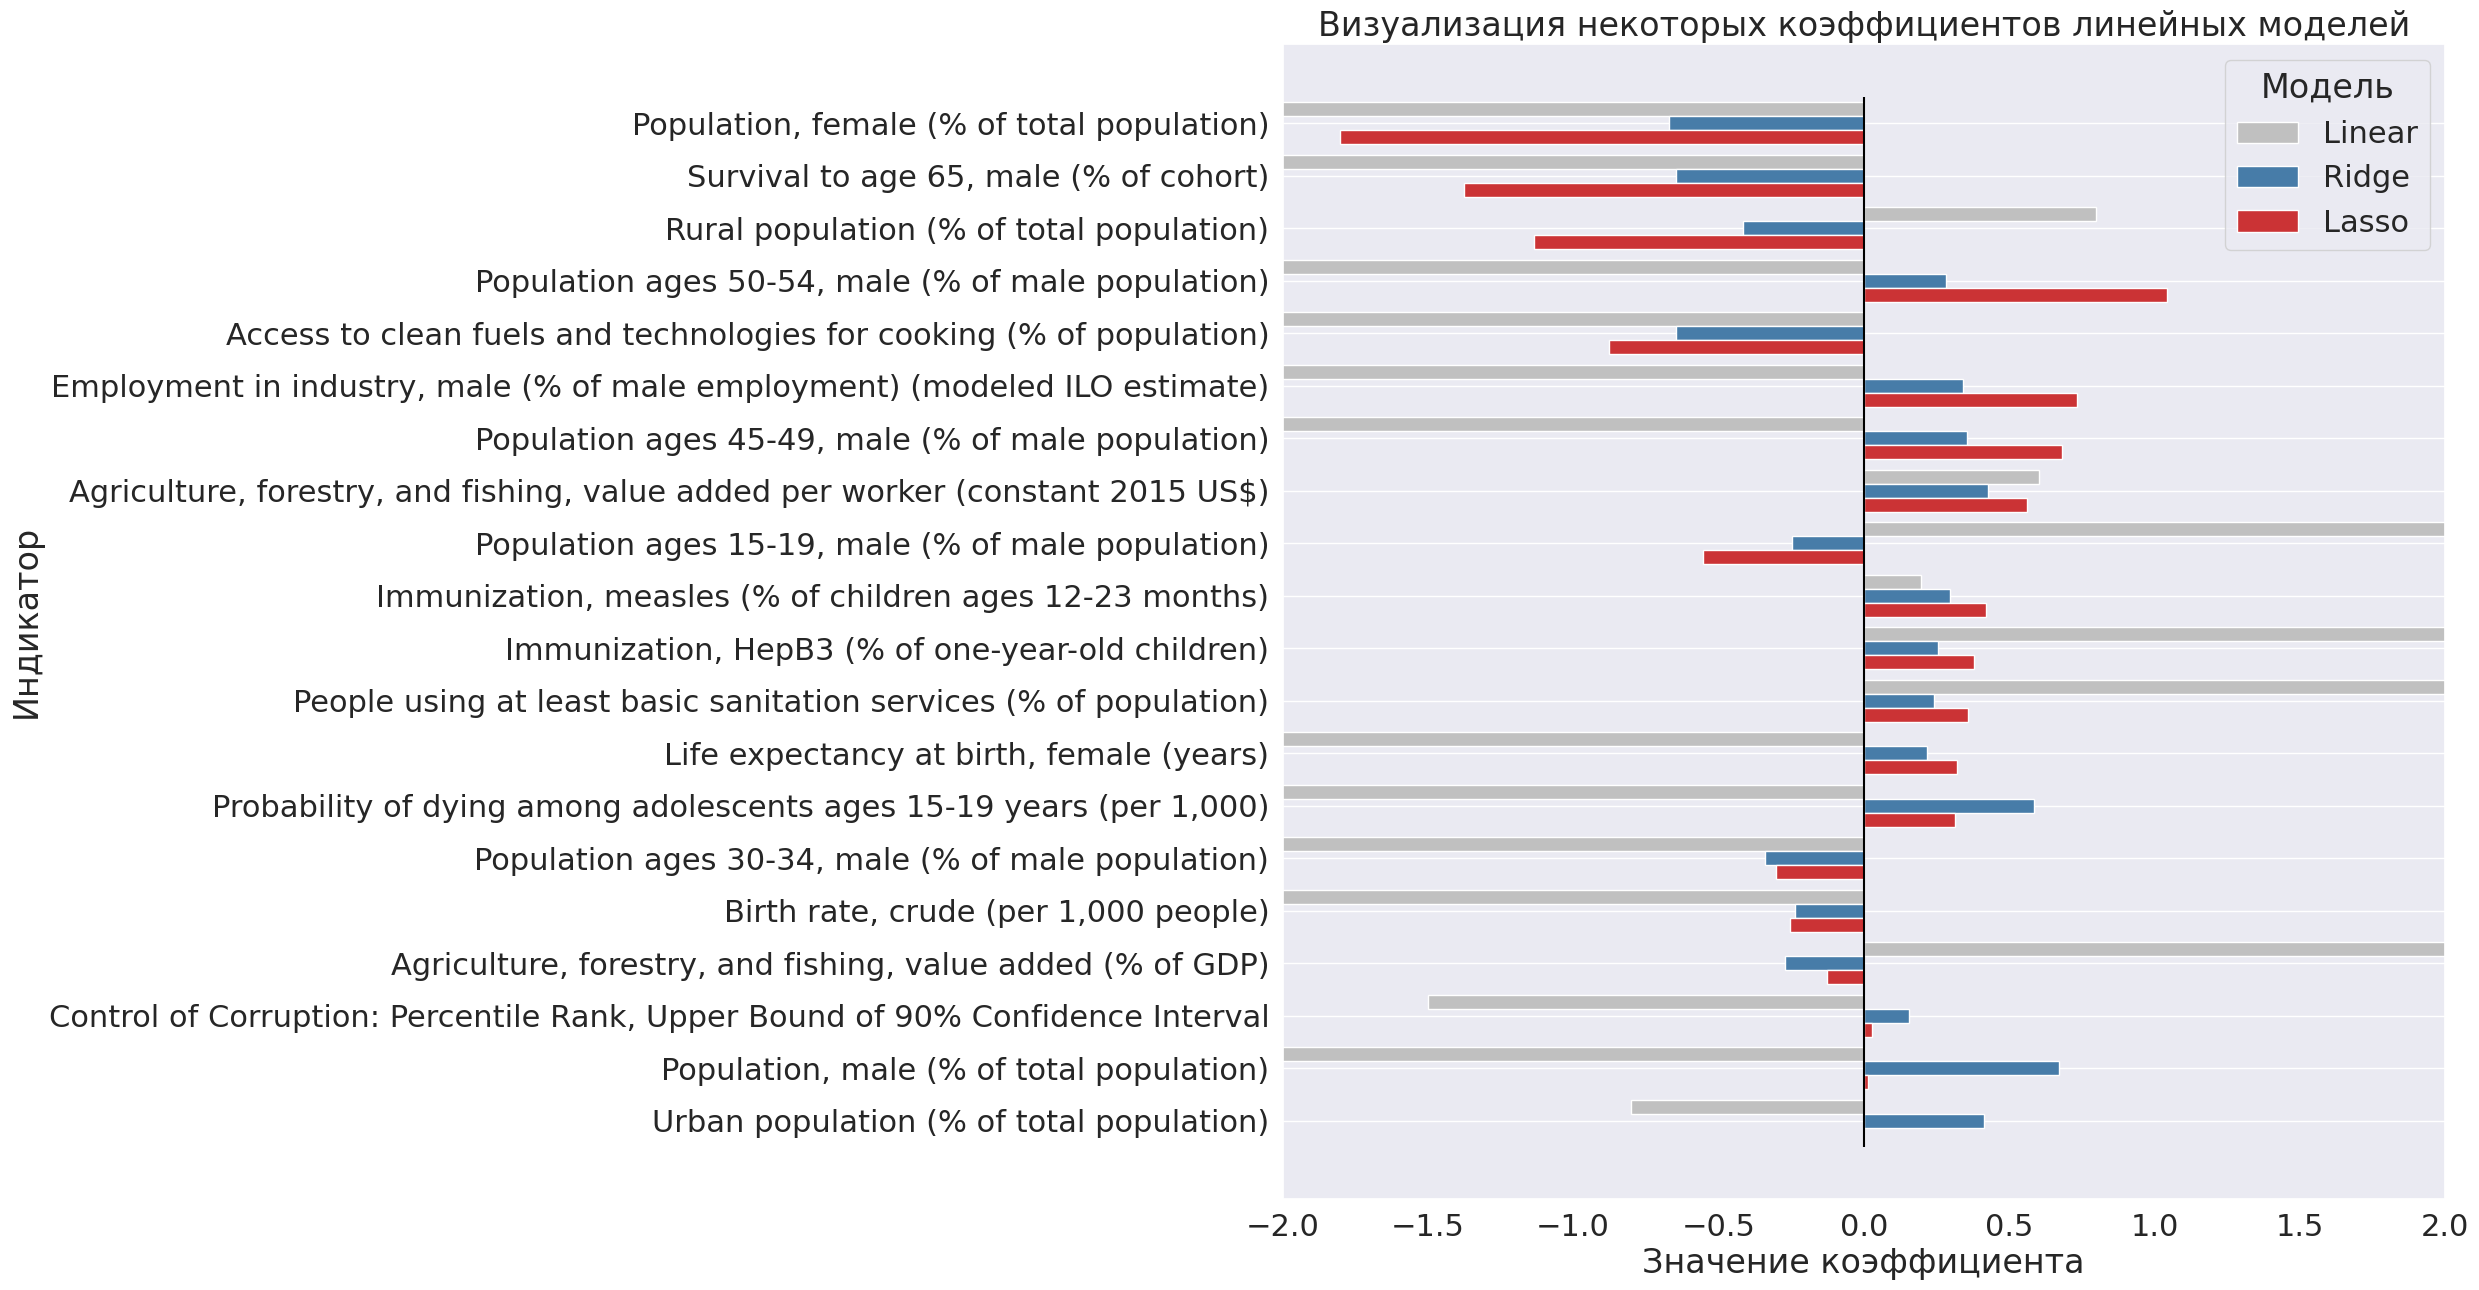

In [41]:
# Выбираем признаки с ненулевыми коэффициентами у Lasso
top_features = coef_df["Lasso"][(coef_df["Lasso"] != 0)].index

# Вытаскиваем аналогичные коэффициенты у МНК и Ridge
top_coef_df = coef_df.loc[top_features].reset_index(names="Индикатор")

# Сортируем по убыванию абсолютных значений коэффициентов Lasso
top_coef_df.sort_values(by="Lasso", key=abs, ascending=False, inplace=True)

# Преобразуем таблицу в "длинный формат" для удобной визуализации
top_coef_df = top_coef_df.melt(
    id_vars="Индикатор", var_name="Модель", value_name="Значение коэффициента"
)

# Визуализация
sns.set_theme(font_scale=2, palette="Set2")
plt.figure(figsize=(15, 15))
sns.barplot(
    data=top_coef_df,
    y="Индикатор",
    x="Значение коэффициента",
    hue="Модель",
    orient="h",
    palette={"Linear": "silver", "Ridge": "#377eb8", "Lasso": "#e41a1c"},
)
plt.grid(which="both")
plt.xlim((-2, 2))
plt.vlines(0, *plt.gca().get_ylim(), color="black")
plt.title("Визуализация некоторых коэффициентов линейных моделей");

**Выводы о влиянии регуляризации на коэффициенты**

1.  Регуляризация уменьшает масштаб коэффициентов: у простой линейной модели они значительно больше, чем у моделей с регуляризацией.
2.  Ridge-регрессия равномерно снижает значения всех коэффициентов. В то же время Lasso выделяет наиболее значимые признаки, присваивая им относительно большие коэффициенты, а остальные зануляет.
3.  В некоторых случаях под воздействием регуляризации может изменяться знак коэффициента.

## 5. Что имеем?

Все построенные модели демонстрируют невысокую предсказательную силу ($R^2$ заметно отличается от 1). Для получения более надёжных оценок необходимо проводить обучение при различных разбиениях на обучающую и валидационную выборки с последующим усреднением метрик и коэффициентов регрессии (т.н. кросс-валидация моделей). Также напомним, что мы ограничились лишь данными за 2022 год. Для более полного анализа имеет смысл повторить те же манипуляции для разных лет и сравнить результаты.

Чтобы сделать математически строгие выводы о значимости признаков на основании коэффициентов линейной модели, необходимо познакомиться с проверкой статистических гипотез, а также с разделом статистики под названием "causal inference".

## Заключение

Мы рассмотрели, как мультиколлинеарность проявляется в реальных данных, и как регуляризация помогает сохранить ключевое преимущество простой линейной модели — её интерпретируемость. Более сложные методы машинного обучения, такие как нейронные сети, случайный лес и градиентный бустинг, безусловно, обладают своими преимуществами, однако интерпретация их структуры часто оказывается сложной задачей, а в некоторых случаях и вовсе невозможной.

